<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [30]:
import pandas as pd

taxi_data = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")

taxi_data[["fare_amount","tip_amount","tolls_amount","total_amount"]].describe()



,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [31]:
longest_trip = taxi_data["trip_distance"].idxmax()

taxi_data.loc[longest_trip, ["fare_amount","tip_amount","tolls_amount","total_amount"]]


fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 8338, dtype: object

<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [32]:
meteor_data = pd.read_csv("data/Meteorite_Landings.csv")

meteor_data = meteor_data.rename(columns = {"mass (g)" : "mass"})

meteor_data = meteor_data.drop(columns = ["reclat","reclong","GeoLocation"])

meteor_data.sort_values(by = "mass", ascending = False, inplace = True)

meteor_data.head()

,name,id,nametype,recclass,mass,fall,year
16392,Hoba,11890,Valid,"Iron, IVB",60000000.0,Found,01/01/1920 12:00:00 AM
5373,Cape York,5262,Valid,"Iron, IIIAB",58200000.0,Found,01/01/1818 12:00:00 AM
5365,Campo del Cielo,5247,Valid,"Iron, IAB-MG",50000000.0,Found,12/22/1575 12:00:00 AM
5370,Canyon Diablo,5257,Valid,"Iron, IAB-MG",30000000.0,Found,01/01/1891 12:00:00 AM
3455,Armanty,2335,Valid,"Iron, IIIE",28000000.0,Found,01/01/1898 12:00:00 AM


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [ ]:
meteor_data["year"] = meteor_data["year"].str.slice(6,10)

meteor_data["year"] = pd.to_numeric(meteor_data["year"])

meteor_data["before_1970"] = (meteor_data["year"] < 1970).astype(int)

meteor_data.sort_values(by = "id", ascending = False, inplace = True)

meteor_data_2 = meteor_data.loc[(meteor_data["id"] >= 10036) & (meteor_data["id"] <= 10040)]

meteor_data_2.head()

,name,id,nametype,recclass,mass,fall,year,before_1970
283,Ensisheim,10039,Valid,LL6,127000.0,Fell,1491.0,1
282,Enshi,10038,Valid,H5,8000.0,Fell,1974.0,0
11651,Enon,10037,Valid,"Iron, ungrouped",763.0,Found,1883.0,1
11650,Enigma,10036,Valid,H4,94.0,Found,1967.0,1


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [ ]:
#there is no id matching 10040

meteor_data["year"].describe()
#The max of 2101 is beyond the current year

count    45425.000000
mean      1991.828817
std         25.052766
min        860.000000
25%       1987.000000
50%       1998.000000
75%       2003.000000
max       2101.000000
Name: year, dtype: float64

There's a meteorite that was reportedly found in the future:

In [35]:
# Your code here


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [ ]:
taxi_data["tpep_dropoff_datetime"] = pd.to_datetime(taxi_data["tpep_dropoff_datetime"])

hourly_taxi_data = taxi_data.resample("h", on = "tpep_dropoff_datetime")[["trip_distance", "fare_amount", "tolls_amount", "tip_amount"]].sum().reset_index()

hourly_taxi_data.sort_values(by = "tip_amount", ascending = False, inplace = True)

hourly_taxi_data.head(5)

,tpep_dropoff_datetime,trip_distance,fare_amount,tolls_amount,tip_amount
9,2019-10-23 16:00:00,10676.95,67797.76,699.04,12228.64
10,2019-10-23 17:00:00,16052.83,70131.91,4044.04,12044.03
11,2019-10-23 18:00:00,3104.56,11565.56,1454.67,1907.64
8,2019-10-23 15:00:00,14.34,213.50,0.00,51.75
12,2019-10-23 19:00:00,98.59,268.00,24.48,25.74


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

Text(0, 0.5, 'Travelers')

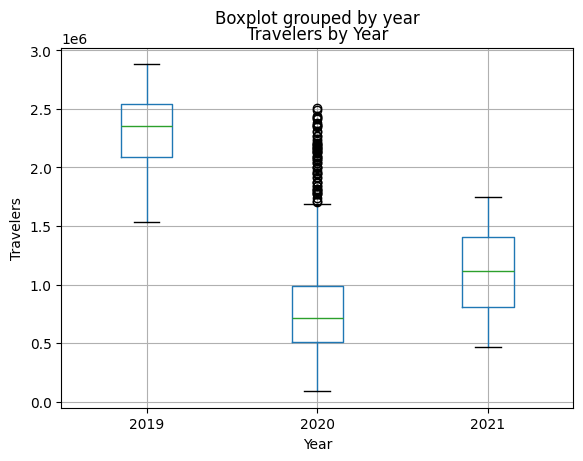

In [76]:
import matplotlib.pyplot as plt

tsa = pd.read_csv("data/tsa_melted_holiday_travel.csv", parse_dates = True, index_col = "date")

tsa.boxplot(column = "travelers", by = "year")

plt.title("Travelers by Year")
plt.xlabel("Year")
plt.ylabel("Travelers")


<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

Text(120.72222222222221, 0.5, 'Day')

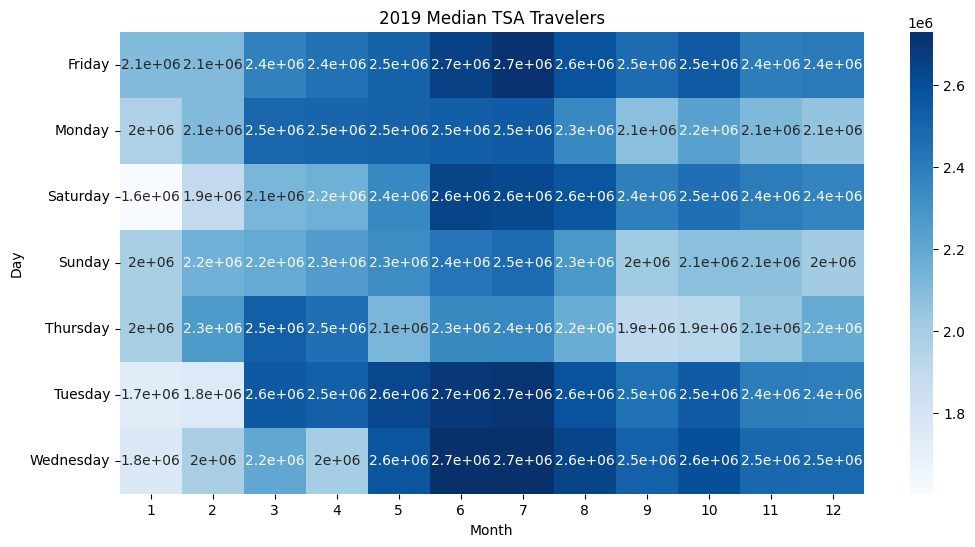

In [81]:
import seaborn as sns

tsa_2019 = tsa[tsa["year"] == 2019]

data = tsa_2019\
    .assign(month = lambda x: x.index.month,
           day = lambda x: x.index.day_name(),
           year = lambda x: x.index.year)\
    .pivot_table(
    index='day',columns='month',
    values='travelers',aggfunc='median')

plt.figure(figsize=(12,6))
ax = sns.heatmap(data, cmap = "Blues", annot = True)
ax.set_title("2019 Median TSA Travelers")
ax.set_xlabel("Month")
ax.set_ylabel("Day")
